# CG con dinamica, solo stelle giganti, no estinzione

Analisi di una simulazione di stelle creata mediante il Besancon model comprendente un cono con un angolo solido di 4 deg^2, centrato nel sole in direzione del centro galattico (l, b = 0) e distanza da 0 a 15 kpc.

Spectral types: da G0 a M5.

Abs Mag = [-7, 1]


Importo il necessario

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
plt.rcParams['agg.path.chunksize'] = 10000

Leggo il dataset

In [2]:
# Apertura e lettura della prima riga per estrarre i nomi delle colonne, escludendo il primo elemento
with open("Simulazione 2 - CG, stelle giganti, 4 deg^2, no estinzione, si dinamica.txt", "r") as file:
    header = file.readline().strip().split()[1:]  # [1:] salta il primo elemento ('#')

# Legge il file saltando la prima riga e usando header personalizzato
df = pd.read_csv("Simulazione 2 - CG, stelle giganti, 4 deg^2, no estinzione, si dinamica.txt", delim_whitespace=True, skiprows=1, names=header)

print(df.head())


        G    G-V    G-I    V-R    V-J    mux     muy    HRV     UU     VV  \
0  10.362  0.306  1.337  0.544  1.725  4.237  -4.526 -37.57 -37.45  -4.64   
1  10.296  0.273  1.264  0.533  1.640 -8.046  -8.197 -53.14 -52.35 -33.41   
2  10.445  0.332  1.405  0.562  1.887 -1.574 -11.431 -26.30 -24.86 -40.17   
3  10.321  0.233  1.279  0.541  1.727 -3.195  -8.108 -28.63 -24.66 -25.95   
4  10.311  0.181  1.240  0.577  1.848  7.808  -7.201   7.88   5.41 -11.52   

   ...  errAge  errTeff  errLogg  errMet  errAlphaFe  errBand_G  errBand_V  \
0  ...     0.1     50.0      0.1     0.1        0.02     0.0186    -0.0138   
1  ...     0.1     50.0      0.1     0.1        0.02    -0.0092    -0.0275   
2  ...     0.1     50.0      0.1     0.1        0.02    -0.0037    -0.0420   
3  ...     0.1     50.0      0.1     0.1        0.02    -0.0401    -0.0025   
4  ...     0.1     50.0      0.1     0.1        0.02    -0.0430     0.0360   

   errBand_I  errBand_R  errBand_J  
0     0.0029     0.0137     0.0

Calcolo ora la velocità di rotazione cartesiana V_y e cilindrica V_phi. Mi aspetto che abbiano un'andamento simile

In [4]:
df["x_Gal"] = -df["x_Gal"] #inverto tutte le coordinate x_gal in quanto impiego formule (slides spagna) basate su un sistema left handed invece che right handed (usato dal Besancon Model)
df["UU"] = -df["UU"] #inverto tutte le coordinate U in quanto impiego formule (slides spagna) basate su un sistema left handed invece che right handed (usato dal Besancon Model)

In [ ]:
print(df["x_Gal"].head())

0    7.2931
1    7.2603
2    7.2375
3    7.2358
4    7.2155
Name: x_Gal, dtype: float64


In [5]:
V_LSR = 244.6 # Velocità di rotazione del Local Standard of Rest rispetto al centro galattico in km/s
R_sun = 8 # Distanza del Sole dal centro galattico in kpc ref. STELLAR POPULATION IN THE MILKY WAY BULGE REGION 2011

# Distanza dal centro galattico della proiezione sul piano xy della stella in kpc
#df["R"] = np.sqrt(((df["Dist"])**2)*(np.cos(df["latitude"]))**2 + R_sun**2 - 2*R_sun*np.cos(df["longitude"])*np.cos(df["latitude"])) 
df["R"] = np.sqrt(df["x_Gal"]**2 + df["y_Gal"]**2) # Distanza dal centro galattico della proiezione sul piano xy della stella in kpc

# Angolo galattico in radianti
#phi = np.arcsin(df["Dist"]*np.sin(df["longitude"])*np.cos(df["latitude"]) / df["R"]) 
phi =np.arctan2(df["y_Gal"], df["x_Gal"]) # Angolo galattico in radianti

df["V_y"] = df["VV"] + V_LSR

df["V_phi"] = df["V_y"]*np.cos(phi) - df["UU"]*np.sin(phi) 
df["V_R"] = df["V_y"]*np.sin(phi) + df["UU"]*np.cos(phi)

Plottiamo la velocità di rotazione cilindrica V_phi e successivamente quella cartesiana V_y in funzione della distanza dal centro nell'asse x, per mostrare il simile comportamento delle due velocità dato dal piccolo campo osservato.

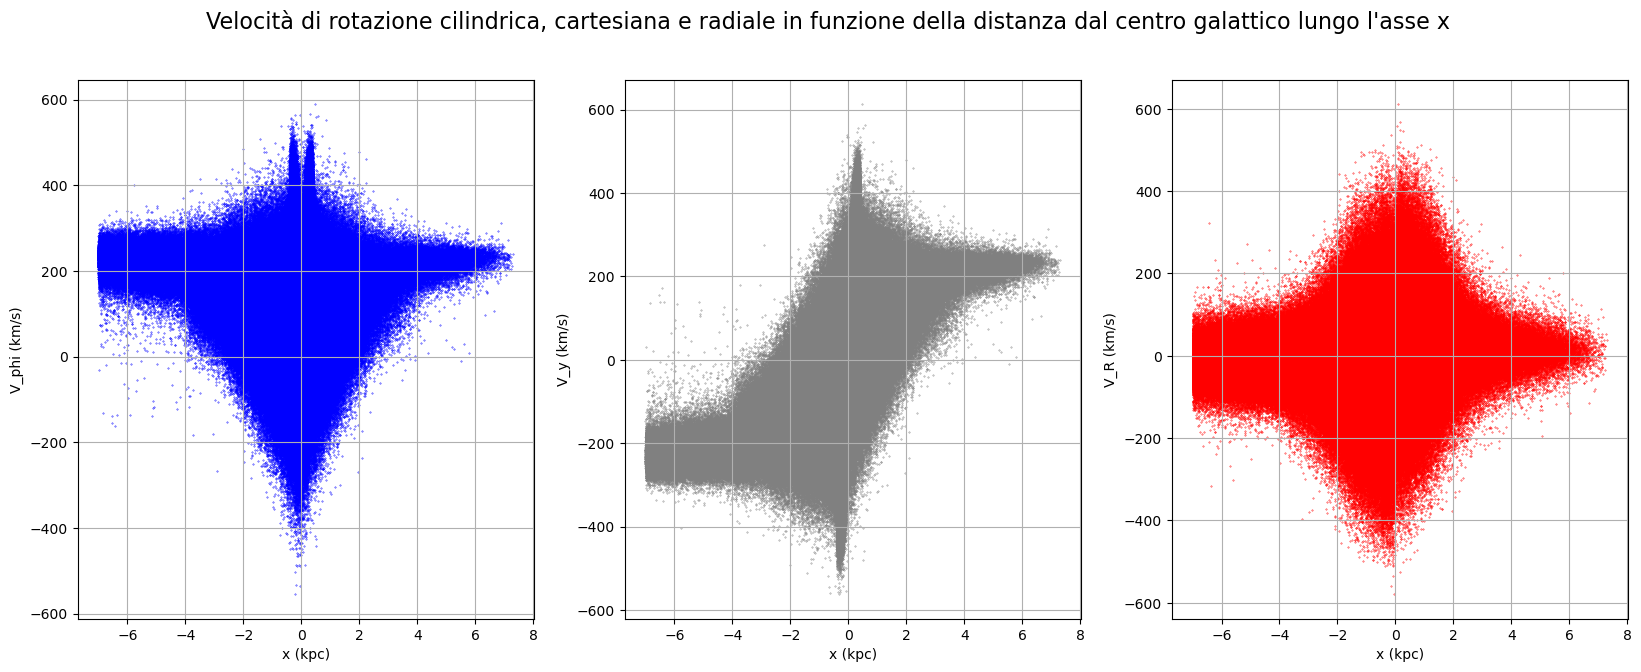

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Velocità di rotazione cilindrica, cartesiana e radiale in funzione della distanza dal centro galattico lungo l'asse x", fontsize=16)
axes[0].scatter(df["x_Gal"], df["V_phi"], color="blue", s=0.1)
axes[0].set_xlabel("x (kpc)")
axes[0].set_ylabel("V_phi (km/s)")
axes[0].grid(True)

axes[1].scatter(df["x_Gal"], df["V_y"], color="gray", s=0.1)
axes[1].set_xlabel("x (kpc)")
axes[1].set_ylabel("V_y (km/s)")
axes[1].grid(True)

axes[2].scatter(df["x_Gal"], df["V_R"], color="red", s=0.1)
axes[2].set_xlabel("x (kpc)")
axes[2].set_ylabel("V_R (km/s)")
axes[2].grid(True)

plt.show()

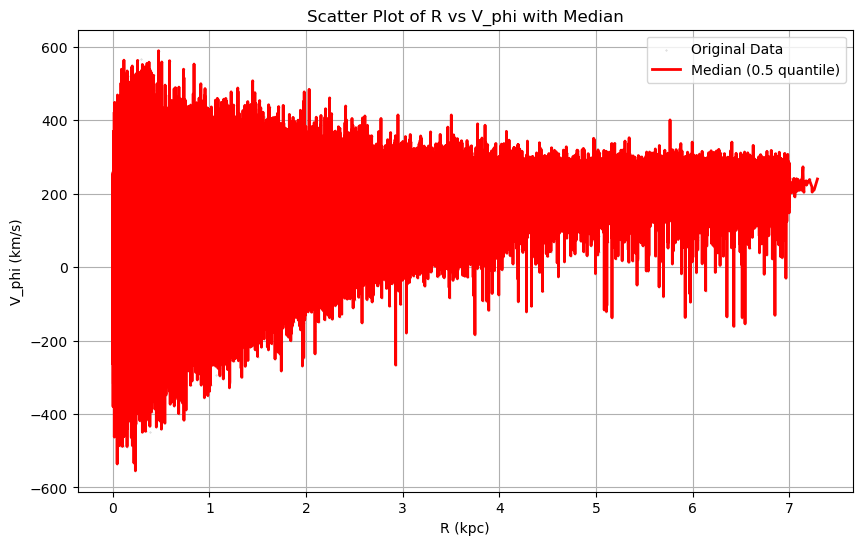

In [ ]:
# Group by R and calculate the median of V_phi
median_V_phi = df.groupby("R")["V_phi"].quantile(0.5)

# Extract unique R values
unique_R = median_V_phi.index.values

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(df["R"], df["V_phi"], s=0.1, alpha=0.5, label="Original Data", color="gray")
plt.plot(unique_R, median_V_phi, color="red", label="Median (0.5 quantile)", linewidth=2)
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Scatter Plot of R vs V_phi with Median")
plt.legend()
plt.grid(True)
plt.show()

Faccio un fit sulle velocità cilindriche delle stelle apparteneti al disco sottile.

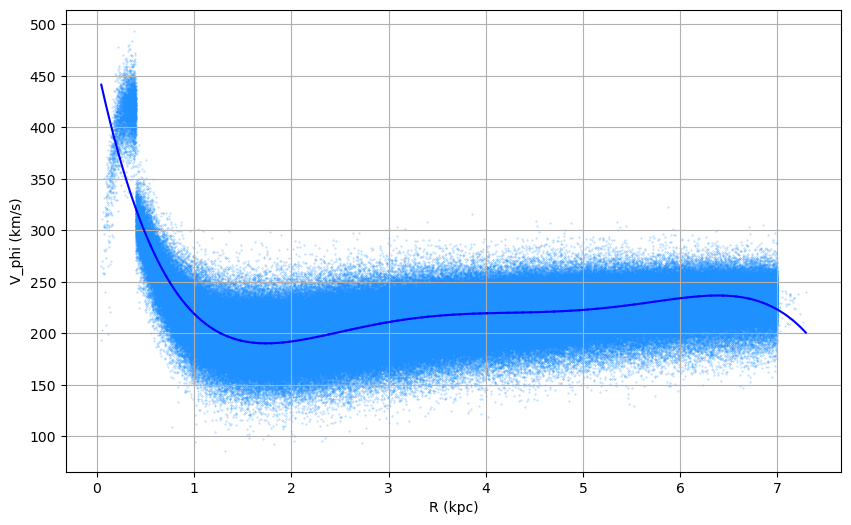

In [12]:
# Seleziono solo le stelle appartenenti al disco sottile  (Pop da 1 a 7)
disk = df[df["Pop"].isin(range(1, 7))]

# Ordino le stelle secondo la vicinanza al centro galattico (dalle più vicine alle più distanti)
disk_sorted = disk.sort_values(by="R")

# Raggrupo le stelle con stessa distanza e calcolo la media delle rispettive V_phi
avgV_phi_disk = disk_sorted.groupby("R")["V_phi"].mean()

# Mi creo due vettori con tutti i raggi presi una sola volta. Tale vettore dovrebbe avere la stessa lunghezza del vettore contenente le velocità
# V_phi medie.
unique_R = np.unique(disk["R"])

# Creo un fit con polinomio di grado 5
coefficienti_del_fit = np.polyfit(unique_R, avgV_phi_disk, deg=5)
y_fit = np.poly1d(coefficienti_del_fit)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(unique_R, y_fit(unique_R), color="blue", label="Curva interpolatoria (grado = 5)")
plt.scatter(disk["R"], disk["V_phi"], s = 0.1 , alpha = 0.5, color="dodgerblue")
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
#plt.title("Velocità rotazionale cilindrica rispetto al centro per stelle di Disco")
#plt.legend()
plt.grid(True)
plt.show()

Interpoliamo i punti trovati per studiare possibili andamenti

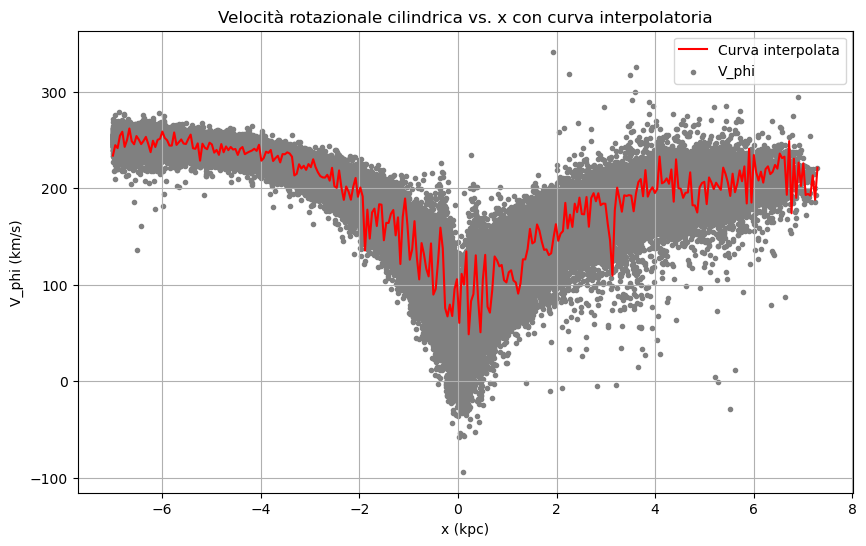

In [66]:
df_sorted = df.sort_values(by="x_Gal") #ordino i valori x_Gal

df_grouped = df_sorted.groupby("x_Gal", as_index=False)["V_phi"].mean() #raggruppo i valori di x e ne calcolo la media

x_unique = df_grouped["x_Gal"].values
y_unique = df_grouped["V_phi"].values

x_new = np.linspace(x_unique.min(), x_unique.max(), 300)

spline = make_interp_spline(x_unique, y_unique, k=1)
y_new = spline(x_new)
plt.figure(figsize=(10, 6))
plt.plot(x_new, y_new, color="red", label="Curva interpolata")
plt.scatter(x_unique, y_unique, marker= ".", color="grey", label="V_phi")
plt.xlabel("x (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Velocità rotazionale cilindrica vs. x con curva interpolatoria")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'population_groups' is not defined

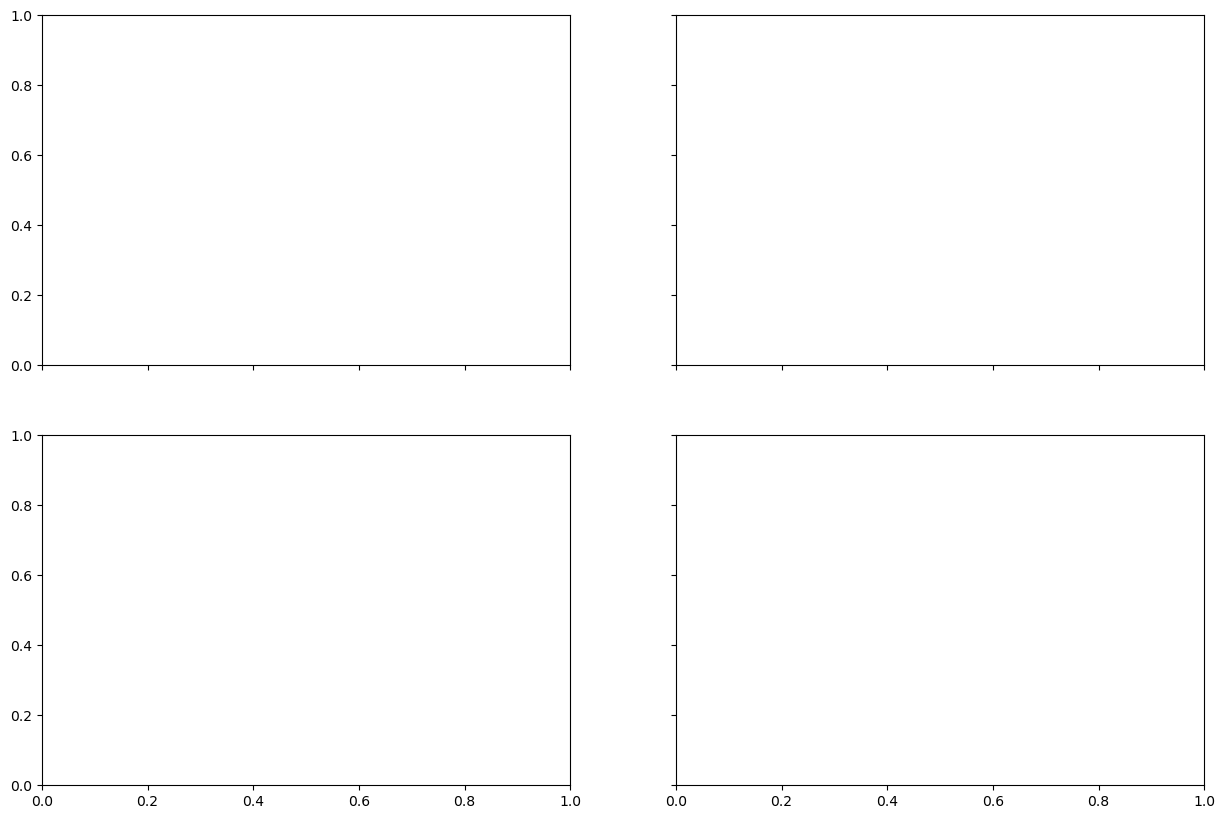

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()
colore = ["blue", "red", "orange", "green"]
popolazione = {"Disco sottile": [1,7], "Disco spesso": 8, }
for i, (group, pops) in enumerate(population_groups.items()):
    subset = df[df["Pop"].isin(pops)]
    axes[i].scatter(subset["x_Gal"], subset["V_phi"], s=0.1, c = colore[i], alpha=0.6, label=group)
    axes[i].set_title(f"Population: {group}")
    axes[i].set_xlabel("x_Gal (kpc)")
    axes[i].set_ylabel("V_phi (km/s)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

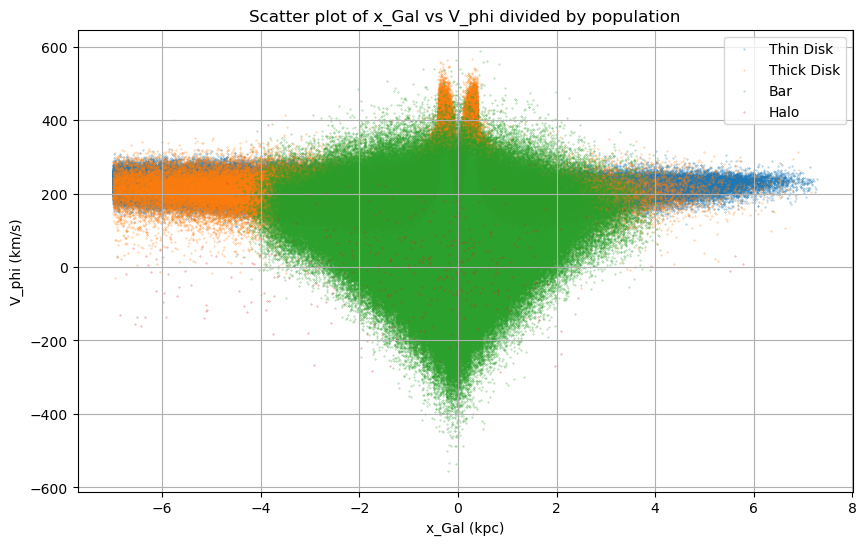

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.scatter(subset["x_Gal"], subset["V_phi"], s = 0.1, alpha=0.6, label=group)

plt.xlabel("x_Gal (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Scatter plot of x_Gal vs V_phi divided by population")
plt.legend()
plt.grid(True)
plt.show()

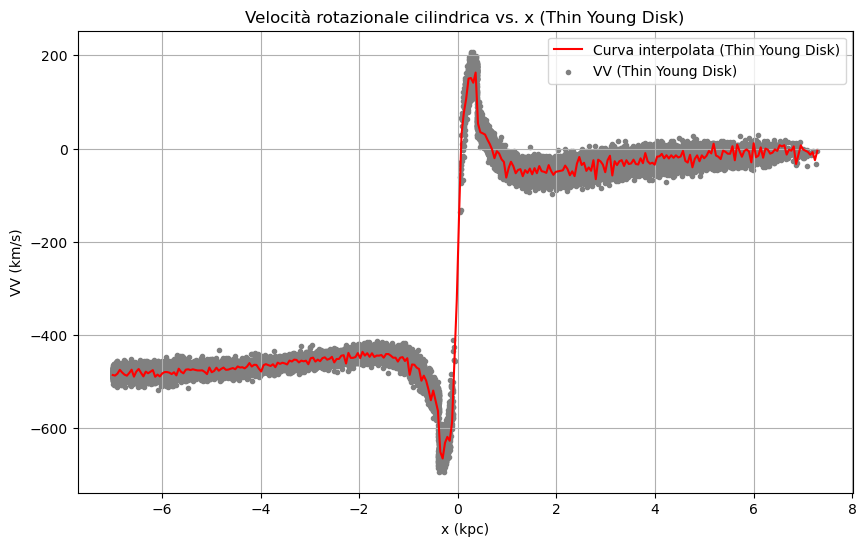

In [ ]:
# Filter the dataframe for populations 1 to 3 (Thin Young Disk)
thin_young_disk = df[df["Pop"].isin([1, 2, 3])]

# Sort values by x_Gal
thin_young_disk_sorted = thin_young_disk.sort_values(by="x_Gal")

# Group by x_Gal and calculate the mean of V_phi
thin_young_disk_grouped = thin_young_disk_sorted.groupby("x_Gal", as_index=False)["VV"].mean()

# Extract unique x and y values
x_unique_thin = thin_young_disk_grouped["x_Gal"].values
y_unique_thin = thin_young_disk_grouped["VV"].values

# Interpolate the data
x_new_thin = np.linspace(x_unique_thin.min(), x_unique_thin.max(), 300)
spline_thin = make_interp_spline(x_unique_thin, y_unique_thin, k=1)
y_new_thin = spline_thin(x_new_thin)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(x_new_thin, y_new_thin, color="red", label="Curva interpolata (Thin Young Disk)")
plt.scatter(x_unique_thin, y_unique_thin, marker=".", color="grey", label="VV (Thin Young Disk)")
plt.xlabel("x (kpc)")
plt.ylabel("VV (km/s)")
plt.title("Velocità rotazionale cilindrica vs. x (Thin Young Disk)")
plt.legend()
plt.grid(True)
plt.show()

Dal grafico notiamo come la velocità di rotazione cresca man mano che ci si sposta dal centro (x = 0), fino a raggiungere all'incirca la velocità del LSR intorno a x = -7,5 kpc, che è esattamente dove si trova il sole. Per x > 0 si ottiene una velocità negativa e simmetrica rispetto a x < 0, perchè rispetto all'osservatore le stelle girano in senso contrario.

Per apprezzarne maggiormente l'andamento, utilizziamo una media mobile con bin = 10000 stelle.

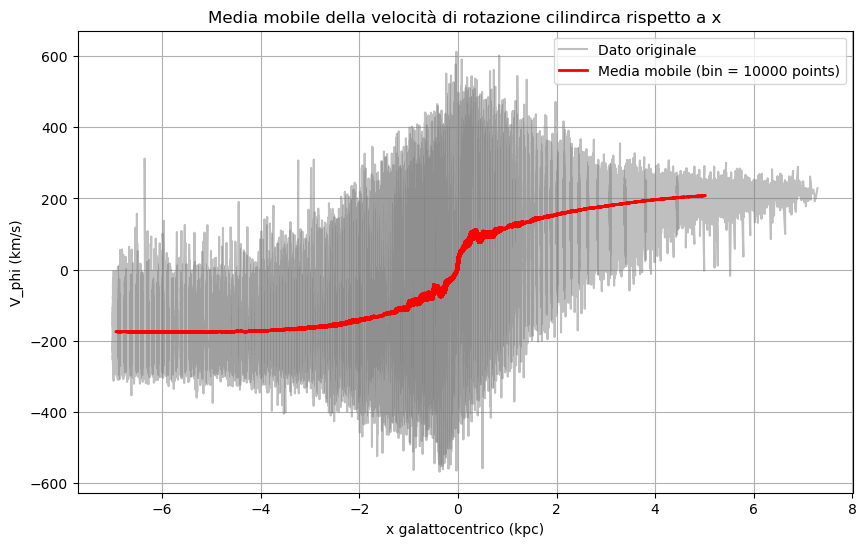

In [ ]:
df['v_phi_moving_avg'] = df['V_phi'].rolling(window=10000, center=True).mean()

plt.figure(figsize=(10, 6))
plt.plot(df['x_Gal'], df['V_phi'], color='gray', alpha=0.5, label='Dato originale')
plt.plot(df['x_Gal'], df['v_phi_moving_avg'], color='red', linewidth=2, label='Media mobile (bin = 10000 points)')
plt.xlabel("x galattocentrico (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Media mobile della velocità di rotazione cilindirca rispetto a x")
plt.legend()
plt.grid(True)
plt.show()

Creiamo ora un istogramma rappresentante il numero di stelle in funzione della magnitudine, in scala logaritmica con bin di 0.25 mag, mostrando anche la distribuzione dei corpi appartenenti al "Disco Sottile", "Disco Spesso" e "Halo".

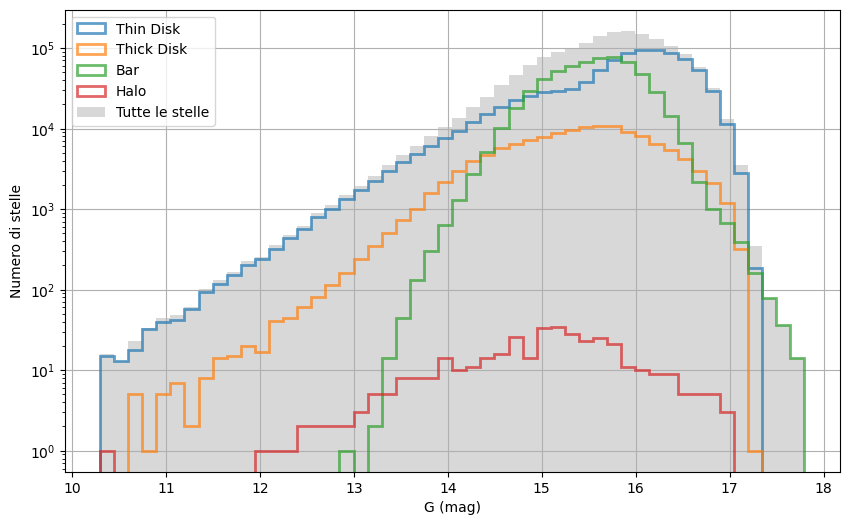

In [3]:
# definisco i gruppi di popolazione in base ai valori di Pop
population_groups = {
    "Thin Disk": [1, 2, 3, 4, 5, 6, 7],
    "Thick Disk": [8, 11],
    "Bar": [10],
    "Halo": [9]
}

plt.figure(figsize=(10, 6))

# loop su ogni gruppo di popolazione e creo un istogramma per ciascuno
for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.hist(subset["G"], bins=np.arange(df["G"].min(), df["G"].max(), 0.15), 
             alpha=0.7, label=group, histtype='step', linewidth=2)
    
plt.hist(df["G"], bins=np.arange(df["G"].min(), df["G"].max(), 0.15), color="gray", alpha=0.3, label = "Tutte le stelle")

plt.yscale('log')
plt.xlabel("G (mag)")
plt.ylabel("Numero di stelle")
#plt.title("Istogramma delle stelle in funzione della Magnitudine apparente (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

Avendo considerato solo la banda da G0 a M5, ottengo una popolazione di stelle giganti ed essendo riferite solo ad una piccola porzione di cielo centrata nel centro della galassia, la maggioranza apparterranno al disco sottile.

Andiamo a rappresentare ora il numero di stelle in funzione delle diverse velocità galattocentriche V_phi, V_z e V_R, mostrando di nuovo la distribuzione dei corpi appartenenti al "Disco Sottile", "Disco Spesso" e "Halo".

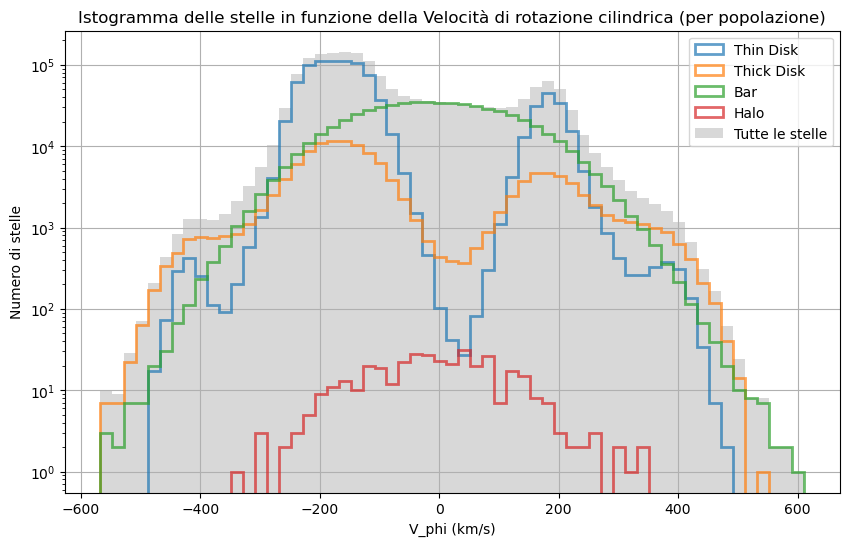

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.hist(subset["V_phi"], bins=np.arange(df["V_phi"].min(), df["V_phi"].max(), 20), 
             alpha=0.7, label=group, histtype='step', linewidth=2)
    
plt.hist(df["V_phi"], bins=np.arange(df["V_phi"].min(), df["V_phi"].max(), 20), color="gray", alpha=0.3, label = "Tutte le stelle")


plt.yscale('log')
plt.xlabel("V_phi (km/s)")
plt.ylabel("Numero di stelle")
plt.title("Istogramma delle stelle in funzione della Velocità di rotazione cilindrica (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

Plottiamo ora l'istogramma riferito alla velocità sull'asse z delle coordinate galattocentriche.

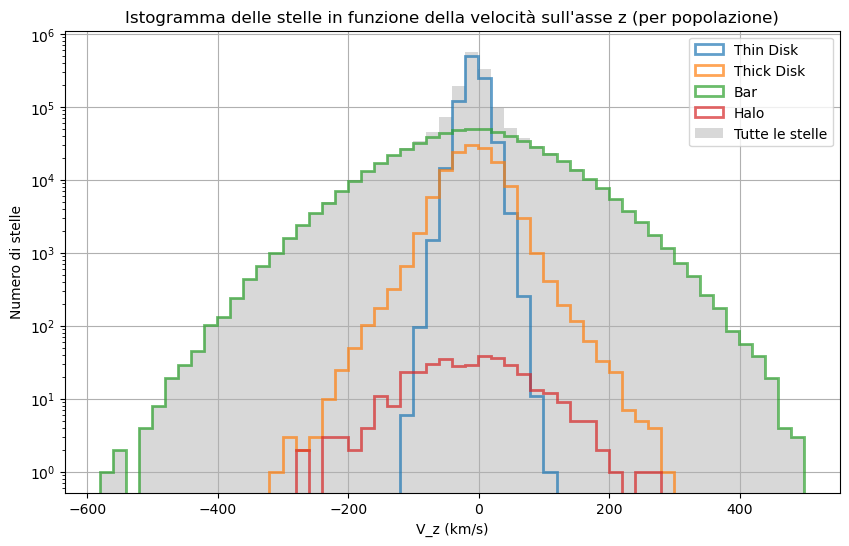

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.hist(subset["WW"], bins=np.arange(df["WW"].min(), df["WW"].max(), 20), 
             alpha=0.7, label=group, histtype='step', linewidth=2)
    
plt.hist(df["WW"], bins=np.arange(df["WW"].min(), df["WW"].max(), 20), color="gray", alpha=0.3, label = "Tutte le stelle")


plt.yscale('log')
plt.xlabel("V_z (km/s)")
plt.ylabel("Numero di stelle")
plt.title("Istogramma delle stelle in funzione della velocità sull'asse z (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

Facciamo ora lo stesso per la velocità radiale V_R

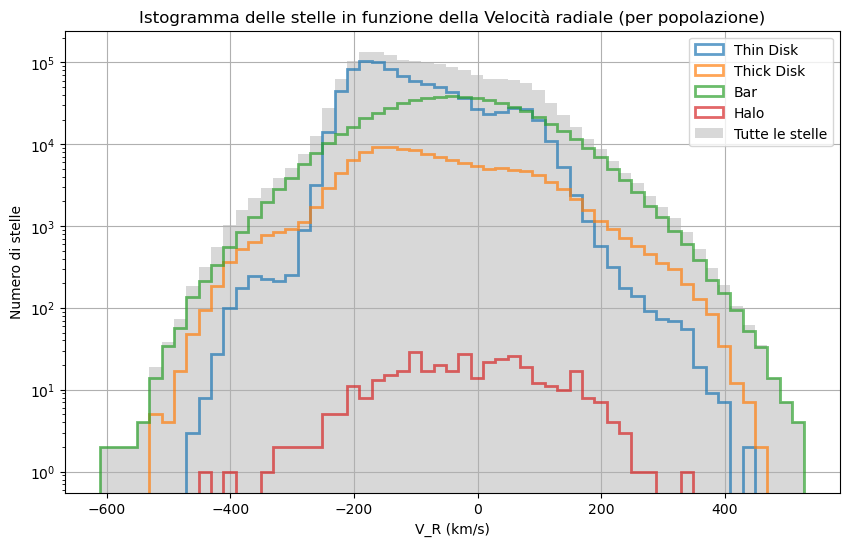

In [ ]:
df["V_R"] = df["V_y"]*np.sin(phi) + df["UU"]*np.cos(phi) #velocità radiale 

plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.hist(subset["V_R"], bins=np.arange(df["V_R"].min(), df["V_R"].max(), 20), 
             alpha=0.7, label=group, histtype='step', linewidth=2)
    
plt.hist(df["V_R"], bins=np.arange(df["V_R"].min(), df["V_R"].max(), 20), color="gray", alpha=0.3, label = "Tutte le stelle")


plt.yscale('log')
plt.xlabel("V_R (km/s)")
plt.ylabel("Numero di stelle")
plt.title("Istogramma delle stelle in funzione della Velocità radiale (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
halo_count = df[df["Pop"].isin(population_groups["Halo"])].shape[0]
print(f"Number of stars classified as Halo: {halo_count}")

Number of stars classified as Halo: 375


Istogramma del numero di stelle in funzione dell'età.

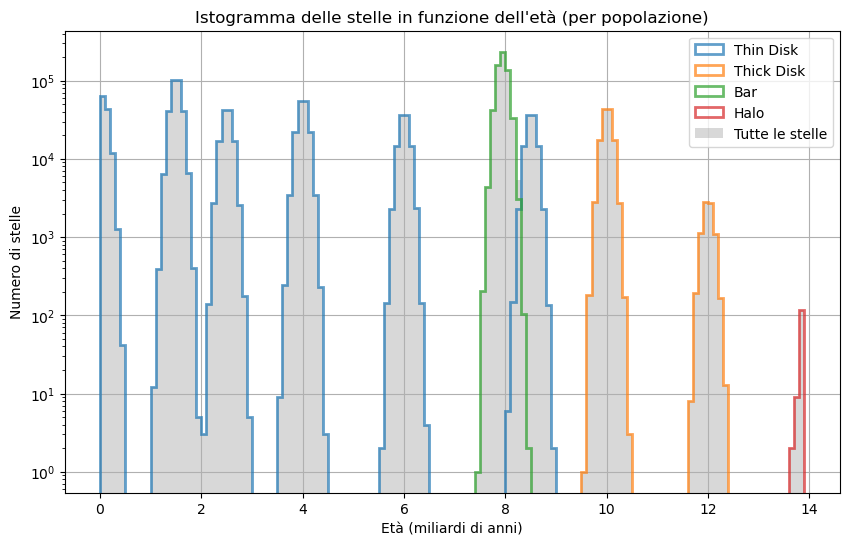

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.hist(subset["Age"], bins=np.arange(df["Age"].min(), df["Age"].max(), 0.1), 
             alpha=0.7, label=group, histtype='step', linewidth=2)
    
plt.hist(df["Age"], bins=np.arange(df["Age"].min(), df["Age"].max(), 0.1), color="gray", alpha=0.3, label = "Tutte le stelle")

plt.yscale('log')
plt.xlabel("Età (miliardi di anni)")
plt.ylabel("Numero di stelle")
plt.title("Istogramma delle stelle in funzione dell'età (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

Istogramma del numero di stelle in funzione della loro metallicità [M/H]

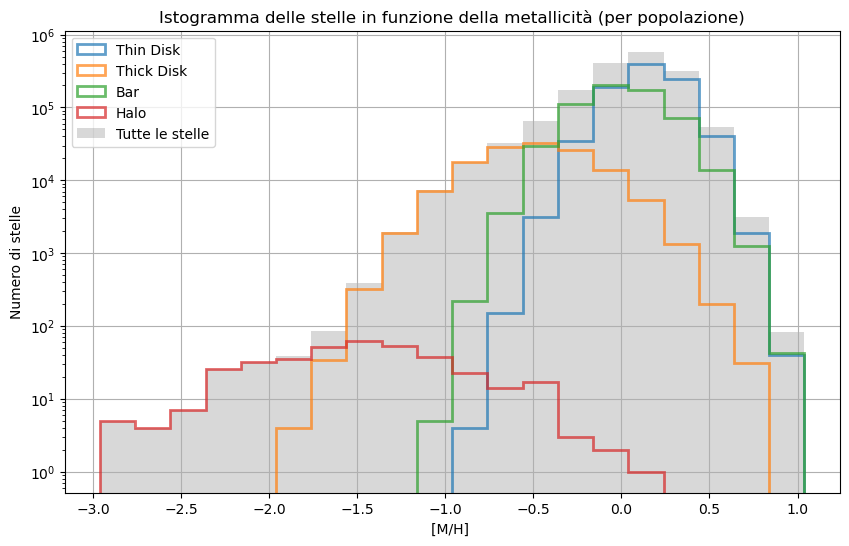

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.hist(subset["[M/H]"], bins=np.arange(df["[M/H]"].min(), df["[M/H]"].max(), 0.2), 
             alpha=0.7, label=group, histtype='step', linewidth=2)
    
plt.hist(df["[M/H]"], bins=np.arange(df["[M/H]"].min(), df["[M/H]"].max(), 0.2), color="gray", alpha=0.3, label = "Tutte le stelle")

plt.yscale('log')
plt.xlabel("[M/H] ")
plt.ylabel("Numero di stelle")
plt.title("Istogramma delle stelle in funzione della metallicità (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

Diagramma metallicità rispetto all'età.

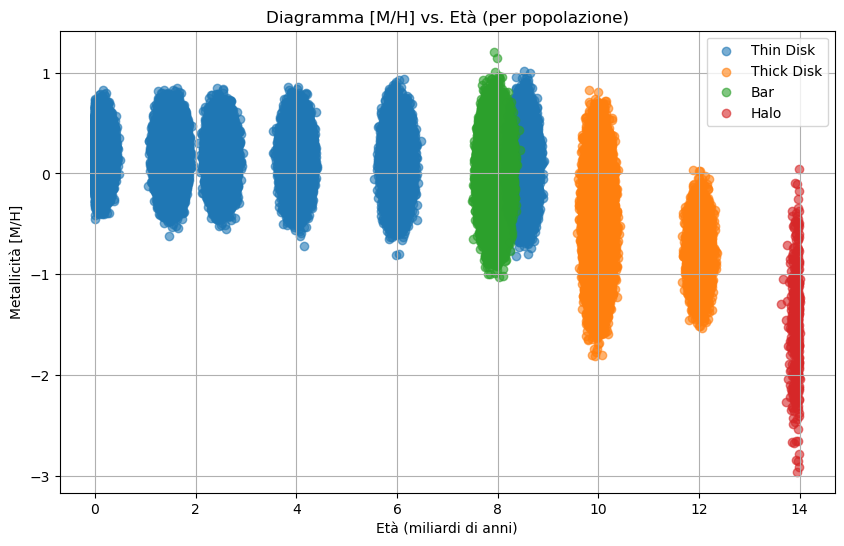

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.scatter(subset["Age"], subset["[M/H]"], alpha=0.6, label=group)

plt.xlabel("Età (miliardi di anni)")
plt.ylabel("Metallicità [M/H]")
plt.title("Diagramma [M/H] vs. Età (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\franc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


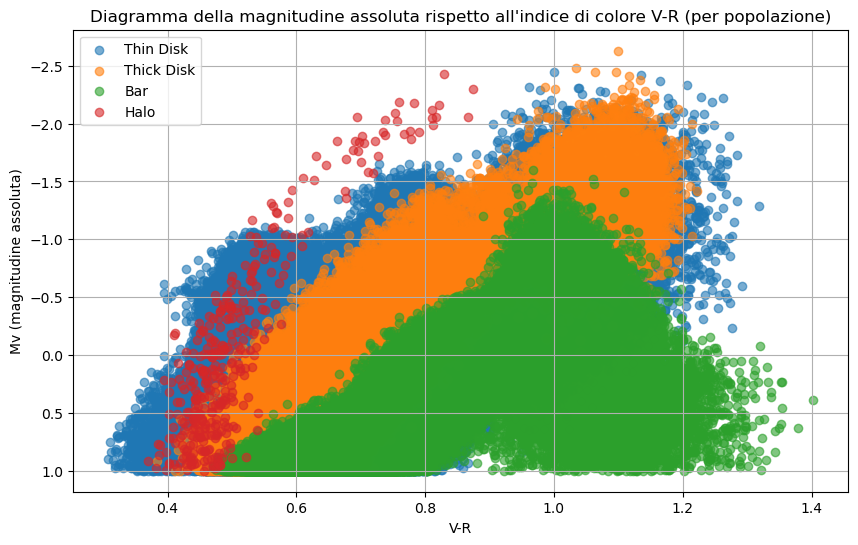

In [ ]:
plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.scatter(subset["V-R"], subset["Mv"], alpha=0.6, label=group)

plt.xlabel("V-R")
plt.ylabel("Mv (magnitudine assoluta)")
plt.gca().invert_yaxis() # Inverte l'asse y per la magnitudine
plt.title("Diagramma della magnitudine assoluta rispetto all'indice di colore V-R (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\franc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


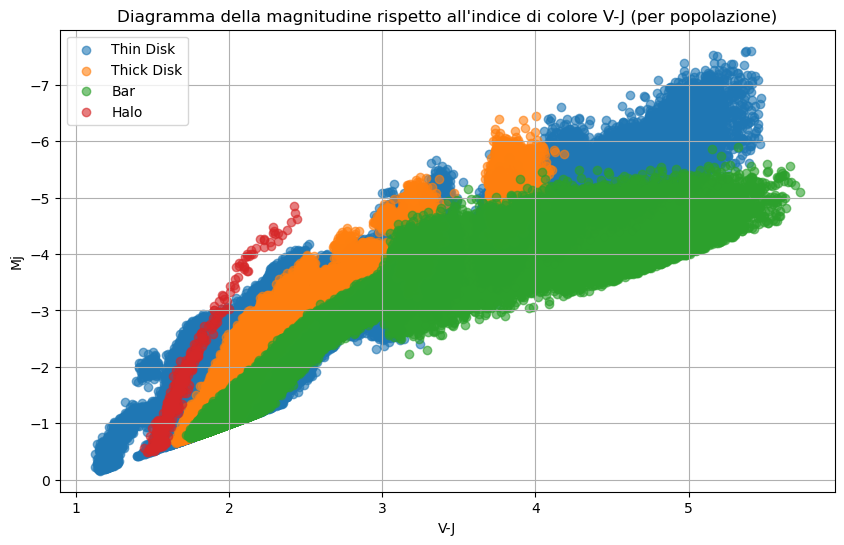

In [ ]:
df["Mj"] = df["Mv"] - df["V-J"] #calcolo la magnitudine Mj

plt.figure(figsize=(10, 6))

for group, pops in population_groups.items():
    subset = df[df["Pop"].isin(pops)]
    plt.scatter(subset["V-J"], subset["Mj"], alpha=0.6, label=group)

plt.xlabel("V-J")
plt.ylabel("Mj")
plt.gca().invert_yaxis()
plt.title("Diagramma della magnitudine rispetto all'indice di colore V-J (per popolazione)")
plt.legend()
plt.grid(True)
plt.show()